# <font color='steelblue'> 280. Modelos de regresión lineal</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

In [ ]:
#@title <font color="steelblue" size="+1"> Configuración del cuaderno
# @markdown Para garantizar la funcionalidad completa de este cuaderno, ejecuta esta celda de código que carga las librerías básicas de Python para el análisis de datos y su representación gráfica.

# Librerías python
##################

# De sistema
from io import StringIO
import sys
# Matemáticas
import numpy as np
import math
# Análisis de datos
import pandas as pd
# Gráficas
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# <font color="steelblue">Descripción del cuaderno</font>

**Descripción:** Los modelos de Regresión Lineal Múltiple permiten analizar la relación entre una variable dependiente de tipo numérico y dos o más variables independientes de tipo numérico. En este cuaderno estudiamos en detalle los fundamentos de estos modelos, presentamos cómo trabajarlos con Python: estimarlos, evaluar la bondad del ajuste, comparar modelos alternativos, seleccionar variables para simplificar modelos sin perder capacidad explicativa, validarlos a través del diagnóstico, o bien proponer correcciones y volver a reajustar para superar el diagnóstico; aprendemos también a trabajar ante problemas de multicolinealidad en los predictores, y a reconocer y tratar observaciones influyentes en el ajuste. Terminamos el cuaderno resolviendo la predicción de la respuesta media o de nuevas observaciones. Ejemplificamos todos los procedimientos propuestos sobre dos bases de datos sencillas.

**Recomendaciones antes de usarlo:** Conocimientos básicos del lenguaje Python, conceptos básicos de probabilidad, análisis exploratorio de datos e inferencia estadística.

**Reconocimiento**: Los contenidos en este cuaderno reutilizan información y funciones existentes en la web [cienciadedatos.net](https://cienciadedatos.net/) sobre regresión lineal múltiple, desarrolladas por Joaquín Amat [CC BY-NC-SA](https://colab.research.google.com/drive/1PIfTa4iLcgIAl5GOGPPXwTfDxG1PSfmd#scrollTo=Wt99G2Jk5jX4&line=9&uniqifier=1), y en el manual de uso de [StatsModels](https://www.statsmodels.org/dev/user-guide.html#regression-and-linear-models) relativo a Regresión Lineal. Se recomiendan ambas referencias al lector que desee ampliar información.

# <font color="steelblue">Contenidos</font>


1. El modelo de regresión lineal múltiple RLM
1. Estimación del modelo
1. Bondad del ajuste
1. Comparación y selección de modelos
1. Diagnóstico del modelo
1. Multicolinealidad e influencia
1. Predicción

# <font color="steelblue">1. El modelo de regresión lineal múltiple (RLM)</font>

Comenzamos presentando los ejemplos con los que trabajaremos:

## Ejemplo 1. Papel

Queremos estudiar la relación existente entre la concentración de madera contenida en la pulpa a partir de la que se elabora papel (`conc`), y la resistencia (`tension`), en términos de la tensión que soporta el papel resultante. El objetivo del análisis es describir y predecir la tendencia observada. En este caso estaríamos ante una modelización con un **modelo de regresión lineal simple**.

In [ ]:
# Vectores de muestras
conc = [1, 1.5, 2, 3, 4, 4.5, 5, 5.5, 6, 6.5, 7, 8, 9, 10, 11,
            12, 13, 14, 15]
tension = [6.3, 11.1, 20.0, 24, 26.1, 30, 33.8, 34, 38.1, 39.9, 42,
             46.1, 53.1, 52, 52.5, 48, 42.8, 27.8, 21.9]
# Dataframe
papel = pd.DataFrame({"conc": conc, "tension": tension})

Investigamos inicialmente si existe relación lineal entre ellas con el valor de la correlación lineal

In [ ]:
papel.corr()

,conc,tension
conc,1.000000,0.552606
tension,0.552606,1.000000


La correlación lineal no es muy alta, indicando una relación lineal pobre. Veamos el gráfico de dispersión para identificar qué tipo de relación existe.

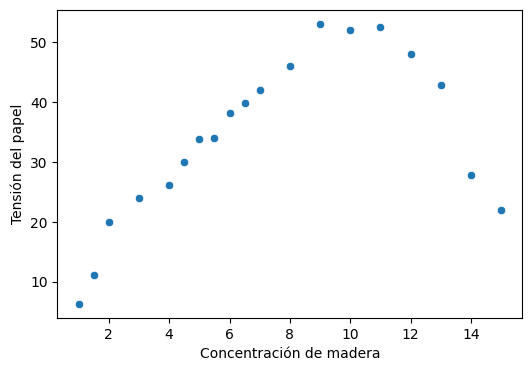

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
gfg = sns.scatterplot(papel, x = "conc",  y = "tension")
gfg.set(xlabel = "Concentración de madera" , ylabel = "Tensión del papel");

Claramente la tendencia observada entre ambas variables es de tipo parabólico, lo que justifica la pobre correlación. Para corroborar las desviaciones, ajustamos una recta a los datos, y luego intentamos capturar la tendencia con un suavizado tipo `lowess`.

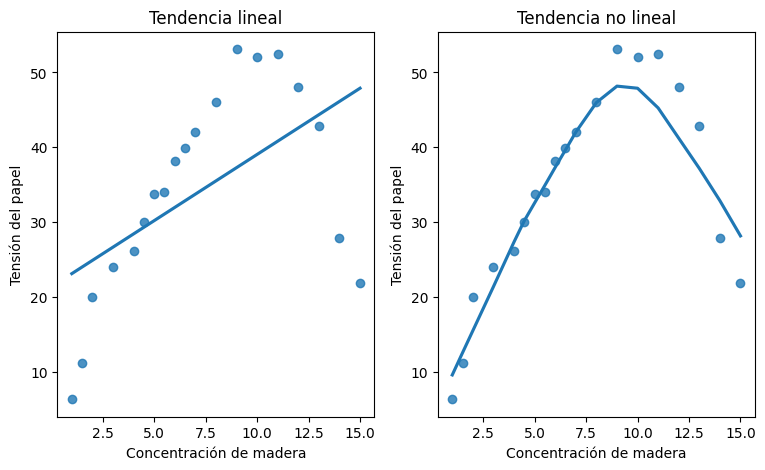

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5))
sns.regplot(papel, x = "conc",  y = "tension", ci = None, ax = ax[0])
ax[0].set(xlabel = "Concentración de madera" , ylabel = "Tensión del papel", title = "Tendencia lineal")
sns.regplot(papel, x = "conc",  y = "tension", ci = None, lowess = True, ax = ax[1])
ax[1].set(xlabel = "Concentración de madera" , ylabel = "Tensión del papel", title = "Tendencia no lineal");

## Ejemplo 2. Madera

Para estimar la producción en madera de un bosque se suele realizar un muestreo previo en el que se realizan una serie de medidas no destructivas. Disponemos de mediciones para 20 árboles, así como el volumen de madera que producen una vez cortados. Las variables consideradas son: ht o altura en pies, dbh el diámetro del tronco a 4 píes de altura (en pulgadas), d16 el diámetro del tronco a 16 pies de altura (en pulgadas), y vol el volumen de madera conseguida (en pies cúbicos). El objetivo del análisis es determinar cuál es la relación entre dichas medidas y el volumen de madera, con el fin de poder predecir este último en función de las primeras.

In [ ]:
# Madera
#  Vectores de muestras
dbh = [10.2, 13.72, 15.43, 14.37, 15, 15.02, 15.12, 15.24, 15.24, 15.28, 13.78,
     15.67, 15.67, 15.98, 16.5, 16.87, 17.26, 17.28, 17.87, 19.13]
d16 = [9.3, 12.1, 13.3, 13.4, 14.2, 12.8, 14, 13.5, 14, 13.8, 13.6, 14,
     13.7, 13.9, 14.9, 14.9, 14.3, 14.3, 16.9, 17.3]
ht = [89, 90.07, 95.08, 98.03, 99, 91.05, 105.6, 100.8, 94, 93.09, 89, 102,
    99, 89.02, 95.09, 95.02, 91.02, 98.06, 96.01, 101]
vol = [25.93, 45.87, 56.2, 58.6, 63.36, 46.35, 68.99, 62.91, 58.13, 59.79,
     56.2, 66.16, 62.18, 57.01, 65.62, 65.03, 66.74, 73.38, 82.87, 95.71]

# Dataframe
bosque = pd.DataFrame({"dbh": dbh, "d16": d16, "ht": ht, "vol": vol})

En primer lugar vemos la asociación entre las variables contenidas en nuestra base de datos:

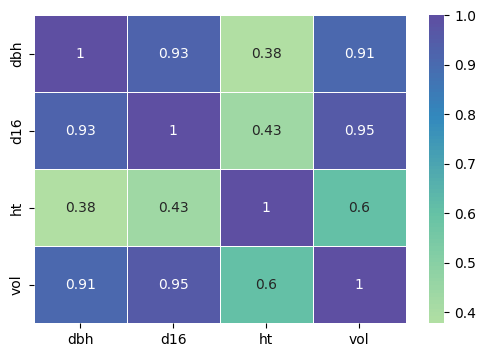

In [ ]:
# matriz de correlaciones
corr_mat = bosque.corr()
# gráfico
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_mat, center = 0, cmap = "Spectral", annot = True,
            linewidths = .5);

Podemos ver que existe una alta correlación entre las predictoras dbh y d16 y con la respuesta vol, pero ht no resulta estar demasiado relacionada con el resto de predictoras y algo con la respuesta. La correlación entre dbh y d16 supone que comparten información, por lo que en la modelización se interferirán entre sí para explicar la respuesta; identificamos ya un problema de multicolinealidad.

Veamos la representación gráfica con los diagramas de dispersión, para verificar si efectivamente se aprecia una relación lineal:

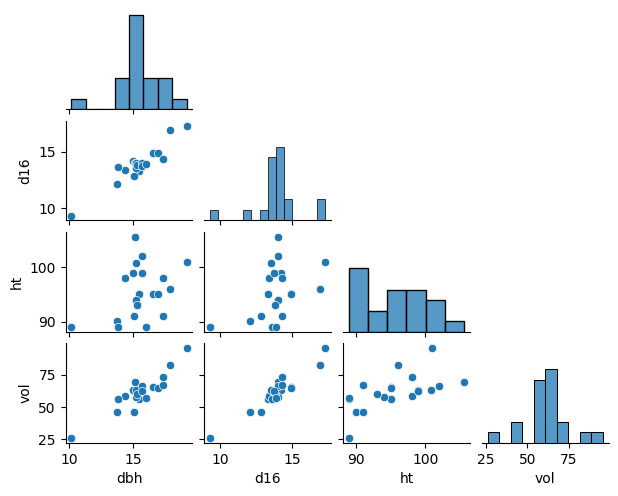

In [ ]:
sns.pairplot(bosque, corner = True, height = 1.25, aspect = 1.25);

En la última fila de la matriz de gráficos podemos ver las relaciones de cada una de las predictoras con la respuesta. Apreciamos linealidad con `dbh` y `d16` con `vol`. Si embargo, la tendencia lineal es más dispersa para la relación `ht-vol`.

Para finalizar representamos a continuación la relación entre los predictores disponibles y la respuesta.

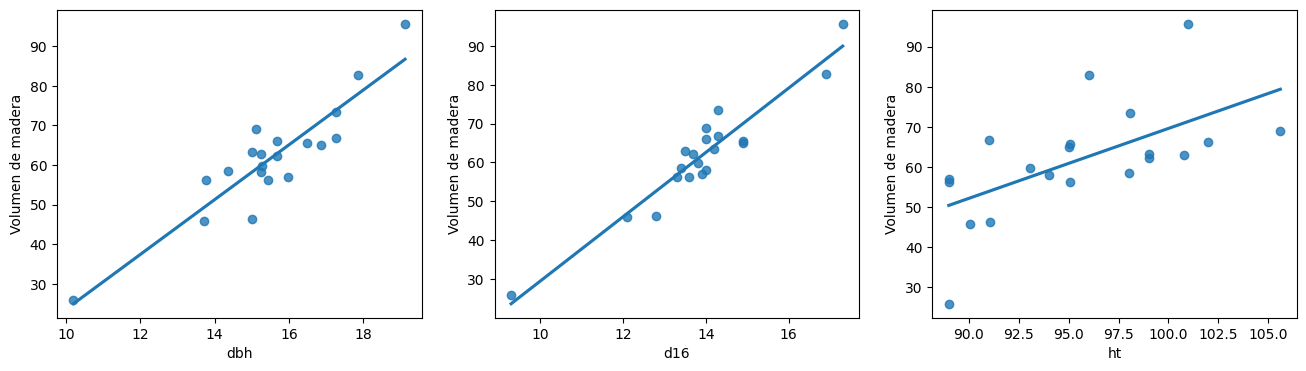

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
sns.regplot(data = bosque, x = "dbh", y = "vol",
            scatter = True, ci = None, ax = axes[0]).set(xlabel = "dbh" , ylabel = "Volumen de madera")
sns.regplot(data = bosque, x = "d16", y = "vol",
            scatter = True, ci = None, ax = axes[1]).set(xlabel = "d16" , ylabel = "Volumen de madera")
sns.regplot(data = bosque, x = "ht", y = "vol",
            scatter = True, ci = None, ax = axes[2]).set(xlabel = "ht" , ylabel = "Volumen de madera");

Y apreciamos que en los tres predictores las nubes de puntos se reparten en torno a una recta, manifestando la relación lineal más o menos severa con la respuesta.

## Propuesta de modelo

El modelo de **regresión lineal múltiple, RLM**, surge cuando queremos explicar cómo se comporta una variable respuesta ($Y$) continua (numérica) a través de un conjunto de $p-1$ variables predictoras ($X_1, X_2, \ldots, X_{p-1}$) también continuas, utilizando una función lineal, que describe posiblemente la relación más simple posible. Escribimos esta relación a través de una superficie (lineal) que difiere de la respuesta en un error aleatorio $\epsilon$, dada por:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_p X_p + \epsilon
$$

Así, asociadas a las observaciones disponibles $\{y_i, i=1,...,n\}$ surgen los errores aleatorios $\{\epsilon_i, i=1,...,n\}$, tales que se distribuyen de forma independiente mediante una distribución Normal de media $0$ y con una varianza constante $\sigma^2$,

$$ \epsilon_i \sim_{iid} N(0,\sigma^2), i =1,...,n$$

El resto de los parámetros desconocidos del modelo, $\beta_0, \beta_1, \beta_2, \ldots, \beta_{p-1}, \sigma^2$, corresponden a:

* $\beta_0$, llamado **intercepción del modelo**. Representa el valor predicho para la variable respuesta cuando los valores de todas las variables predictoras valen $0$. Viene a ser un efecto común compartido por todos los predictores para explicar la respuesta.

* $\beta_j$, para $j \neq 0$, es decir, $j=1, 2, \ldots, p-1$, o **pendientes del modelo**. Estos parámetros hacen referencia al aumento o disminución del valor de la respuesta cuando aumentamos en una unidad el valor de la predictora correspondiente. En este tipo de modelo, este parámetro también se conoce como el efecto de la predictora $j$ sobre la respuesta.

* $\sigma^2$ o **varianza residual del modelo**, que viene a representar la variabilidad en la respuesta que no ha podido ser explicada por el modelo.

Con todo esto, y si suponemos que tenemos una muestra con $n$ sujetos, a partir de las observaciones disponibles para  la variable respuesta $(y_1, y_2, \ldots, y_n)$, y los valores en cada una de las predictoras $X_j$, $\{(x_{1j}, x_{2j}, \ldots, x_{nj}); j=1,...,p-1\}$, podemos escribir el modelo de regresión lineal múltiple matricialmente como :

$$
Y = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix} = \begin{pmatrix} 1 & x_{11} & x_{12} & \ldots & x_{1,p-1} \\ 1 & x_{21} & x_{22} & \ldots & x_{2,p-1} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \ldots & x_{n,p-1} \end{pmatrix} \begin{pmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \vdots \\ \beta_{p-1} \end{pmatrix} + \begin{pmatrix} \epsilon_1 \\ \epsilon_2 \\ \vdots \\ \epsilon_n \end{pmatrix} = X \beta + \epsilon
$$

En este situación, la matriz que contiene la columna de $1's$ y las relativas a cada predictora, $X_j$, la denotaremos por $X$ y se denomina **matriz de diseño**. En la primera columna (la de $1's$) se representa el **efecto común** ($\beta_0$), y en las siguientes, el **efecto de cada una de las predictoras** $X_j$. Finalmente, $\epsilon_i$ representa el error aleatorio para cada observación $i$ de la muestra.

Así por ejemplo, podríamos plantear un modelo RLM para predecir el gasto medio (`gasto_medio`) de una familia, a partir del número de hijos (`n_hijos`) y de los ingresos mensuales (`ing_mensuales`) según:

$$
\text{gasto_medio} = \beta_0 + \beta_1 \text{n_hijos} + \beta_2 \text{ing_mensuales} + \epsilon
$$


En este cuaderno aprenderemos a ajustar modelos de regresión lineal múltiple, seleccionar qué variables son realmente necesarias, validar el modelo, y utilizarlo para predecir la respuesta, del modo más simple posible.

# <font color="steelblue">2. Estimación del modelo</font>

El proceso para ajustar un modelo de regresión lineal múltiple se basa en el ajuste por el método de mínimos cuadrados, es decir en la minimización del error cuadrático medio entre los valores de la respuesta y las predicciones del modelo sobre los datos disponibles. Si utilizamos la hipótesis de normalidad establecida sobre los errores del modelo, dicha optimización se hace en base a dicha distribución, y consiste en conseguir la máxima verosimilitud, que en este modelo coincide con la solución que da el mínimo error cuadrático medio.

Uno de los problemas frecuentes en este modelo proviene del hecho de considerar diversas predictoras, expresadas en diferentes escalas de medida. De ahí que si mantenemos las escalas originales, el modelo que se obtiene, representado por los coeficientes, mantendrá la dependencia de dichas escalas, pudiendo llegar a provocar que una variable con una pequeña variabilidad aparezca con un coeficiente grande en el modelo estimado. Si queremos evitar esta dependencia, podemos trabajar con las variables estandarizadas. Para estandarizar las predictoras tendremos que corregir sus valores por sus medias y desviaciones típicas, eliminando así el efecto de la escala.  En la definición teórica del modelo de RLM no haremos alusión a esta estandarización, pero en la práctica resolveremos toda la modelización con las variables estandarizadas.

## Estimación por máxima verosimilitud

Para el modelo RLM podemos despejar el error del modelo $\epsilon = Y - X \beta$ de forma que la expresión para el error cuadrático medio se puede expresar matricialmente como:

$$
ECM = \epsilon ' \epsilon = (Y - X \beta)' (Y - X \beta) = Y'Y -2 \beta' X' Y + \beta' X' X \beta.
$$

La solución para la estimación de los parámetros el modleo utilizando el estimador por mínimos cudrados es:

\begin{equation}
\hat{\beta}=(X'X)^{-1}X'Y \\
\hat{\sigma^2} = (Y-X\hat{~\beta})'(Y-X\hat{~\beta})/n
\end{equation}

Si los errores se distribuyen según una distribución Normal, podremos obtener la distribución de los estimadores de la varianza, coeficientes y predicciones, con las que resolver las inferencias basadas en estimaciones en intervalo o contrastes de hipótesis sobre los parámetros $\beta$ y $\sigma^2$ del modelo.


### Varianza residual del modelo

Puesto que la varianza residual del modelo $\sigma^2$ expresa cuánta varianza deja sin explicar el modelo propuesto, para estimarla echamos mano de la **suma de cuadrados residual ($SSE$)**, que representa la varianza que ha quedado sin explicar por el modelo estimado, esto es:

$$
SSE = \sum_{i=1}^n (y_i - \hat{y_i})^2 = e'e $$


Puesto que proponemos estimar un total de $p$ parámetros $\beta$, incluida la interceptación, a partir de un total de $n$ observaciones, el número de grados de libertad para conseguir la estimación, o lo que es lo mismo, el margen de estimación que tenemos, es $n-p$. Así se define el **cuadrado medio residual $MSE$**, como el cociente entre $SSE$ y los grados de libertad del modelo:

$$
s^2 = MSE = \frac{SSE}{n-p}
$$


### Coeficientes del modelo

Haciendo uso de la hipótesis de normalidad de los errores aleatorios del modelo ($\epsilon$), el estimador máximo-verosímil $\hat{\beta~}$ sigue también una distribución Normal:

$$
\hat{\beta~} \sim N(\beta,~ \sigma^2 (X'X)^{-1})
$$

A partir de la distribución  de los $\hat{\beta_j}$, resulta posible establecer los contrastes de hipótesis individuales sobre si el coeficiente es significativo o no, o lo que es lo mismo, sobre si realmente la variable $X_j$ es significativa para explicar linealmente la respuesta $Y$:

$$
\left\lbrace\begin{array}{c} H_0: \beta_j = 0 \\ H_1: \beta_j \neq 0 \end{array}\right.
$$


## <font color='steelblue'>Estimación con Python</font>

Una vez repasados los fundamentos teóricos del modelo RLM, procedemos a mostrar cómo resolver las inferencias con la librería `statmodels` de Python.

Para dicho proceso utilizamos la clase `statsmodels.regression.linear_model`, que permite la regresión por mínimos cuadrados ordinarios con la función `OLS`. El código abreviado para ajustar un modelo RLM a un banco de datos específico a través de las matrices respuesta $Y$ y predictora $X$, es el siguiente, importando el módulo `statsmodels.api`:

```
# Cargamos la clase de ajuste del modelo lineal
import statsmodels.api as sm

# Cargamos el banco de datos
df = pd.read_csv('your_data.csv')

# Definimos los conjuntos de variables de interés para el modelo
X = df['independent_variables']
y = df['response_variable']
# Añadimos la constante en la matriz de diseño
X = sm.add_constant(X)

# Ajustamos el modelo
model = sm.OLS(y, X).fit()

# Obtenemos el resumen del ajuste
print(model.summary())
```

En el caso de que queramos utilizar la formulación del modelo de regresión para especificar un determinado orden en la introducción de los regresores, utilizaremos la siguiente sintaxis:

```
# importamos el módulo para el ajuste con fórmula
import statsmodels.formula.api as smf

#  y ajustamos el modelo con una fórmula
model = smf.ols('respuesta ~ pred1 + pred2 +...',data = df).fit()
```

Nos resultará también útil, una función que nos permita estandarizar las variables predictoras, esto es, restarles su media y dividirlas por su desviación típica, que definimos y cargamos a continuación, junto con la clase de ajuste del modelo lineal.

In [ ]:
# Clase de ajuste del modelo lineal
import statsmodels.api as sm


# Función para estandarizar variables de una base de datos
def estandarizar(df, lista_variables):
  """
  Estandariza las variables en el dataframe df, detalladas en la lista lista_variables.

  Parámetros:
    - df: base de datos
    - lista_variables: lista con los nombres de las variables numéricas a estandarizar

  Devuelve el mismo dataframe con una columna adicional por cada una de las contenidas en
  la lista, identificadas con el sufijo '_est'.
  """
  # Recorremos la lista con las variables numéricas
  for i in lista_variables:
    # para cada variable "i", le añadimos el sufijo _est y la correjimos por sumedia y desviación típica
    df[f"{i}_est"] = (df[i] - df[i].mean())/df[i].std()

Para representar gráficamente el ajuste, podemos utilizar la función **[`plot_partregress_grid`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.regressionplots.plot_partregress_grid.html)**, que proporciona un gráfico de dispersión de cada predictor versus la predicción, condicionados ambos al resto de predictores en el modelo, esto es, representa $\hat{Y}$ versus $X_p$ superponiendo la recta de regresión dada por $\hat{Y~}=\hat{\beta_p} X_p$.
```
from statsmodels.graphics.regressionplots import plot_partregress_grid

fig = plt.figure(figsize=(8, 6))
plot_partregress_grid(model, fig=fig)
plt.show()
```



A continuación mostramos el proceso de estimación del modelo para los bancos de datos en los ejemplos 1 y 2.


### Ejemplo 1. Papel



Preparamos los datos en primer lugar, pero no es necesario estandarizar puesto que tenemos un único regresor.

In [ ]:
papel

,conc,tension
0,1.0,6.3
1,1.5,11.1
2,2.0,20.0
3,3.0,24.0
4,4.0,26.1
5,4.5,30.0
6,5.0,33.8
7,5.5,34.0
8,6.0,38.1
9,6.5,39.9


In [ ]:
# Respuesta
Y_papel = papel['tension']
# Matriz de diseño
X_papel = sm.add_constant(papel['conc'])

In [ ]:
X_papel

,const,conc
0,1.0,1.0
1,1.0,1.5
2,1.0,2.0
3,1.0,3.0
4,1.0,4.0
5,1.0,4.5
6,1.0,5.0
7,1.0,5.5
8,1.0,6.0
9,1.0,6.5


Ajustamos ahora el modelo lineal, aun sabiendo que no es adecuado, como ya vimos anteriormente (la tendencia observada no era lineal sino parabólica).

In [ ]:
# Ajuste del modelo
fit_papel = sm.OLS(Y_papel, X_papel).fit()
# Resumen del modelo
print(fit_papel.summary())

                            OLS Regression Results                            
Dep. Variable:                tension   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     7.474
Date:                Thu, 27 Feb 2025   Prob (F-statistic):             0.0141
Time:                        10:42:15   Log-Likelihood:                -72.823
No. Observations:                  19   AIC:                             149.6
Df Residuals:                      17   BIC:                             151.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.3213      5.430      3.926      0.0

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


En este caso estamos ante un modelo de regresión lineal simple, dado que solo disponemos de una predictora, cuya ecuación viene dada por:

$$\widehat{tension} = 21.3213 + 1.7710 \cdot conc$$

Podemos representar el modelo obtenido haciendo uso de la función `regplot` de la librería `seaborn`.

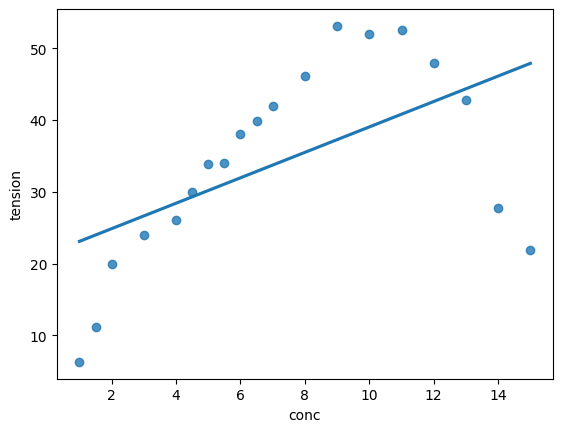

In [ ]:
# Creamos dataframe
datos = pd.concat([Y_papel, X_papel], axis = 1)
# Representamos la solución del modelo
sns.regplot(datos, x = "conc", y = "tension", ci = None);

El modelo obtenido no reproduce el comportamiento observado, por lo que resulta necesario una modificación que estudiaremos más adelante.

Podríamos haber estandarizado la predictora (llamándola $conc_e$), y entonces la recta de regresión sería diferente, pero todos los descriptivos del modelo coinciden. En concreto se obtiene:

$$\widehat{tension} = 34.1842 + 7.6137 \cdot conc_e$$

donde $conc_e$ es la variable $conc$ estandarizada.

Veamos como obtener dicho modelo:

In [ ]:
# Construímos la matriz de explicativas quitando la respuesta
X_papel = papel.drop(columns=['tension'])
# Guardamos los nombres de las predictoras
nombres_papel = X_papel.columns
# Predictoras estandarizadas
estandarizar(X_papel, nombres_papel)
X_papel.head()

,conc,conc_est
0,1.0,-1.456846
1,1.5,-1.340543
2,2.0,-1.224240
3,3.0,-0.991634
4,4.0,-0.759029


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


                            OLS Regression Results                            
Dep. Variable:                tension   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     7.474
Date:                Thu, 27 Feb 2025   Prob (F-statistic):             0.0141
Time:                        10:42:15   Log-Likelihood:                -72.823
No. Observations:                  19   AIC:                             149.6
Df Residuals:                      17   BIC:                             151.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.1842      2.711     12.611      0.0

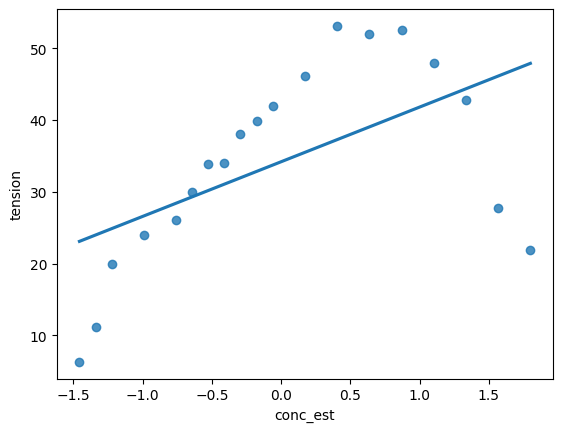

In [ ]:
# nombres variables estandarizadas
nombres_papel_est = X_papel.filter(like = '_est', axis = 1).columns
# Matriz de diseño
Xest_papel = sm.add_constant(X_papel[nombres_papel_est])
# ajuste del model
fit_papel_est = sm.OLS(Y_papel, Xest_papel).fit()
# Resumen del modelo
print(fit_papel_est.summary())

# visualizamos el ajuste
# Creamos dataframe
datos = pd.concat([Y_papel, Xest_papel], axis = 1)
# Representamos la solución del modelo
sns.regplot(datos, x = "conc_est", y = "tension", ci = None);

### Ejemplo 2. Madera



Identificamos la variable respuesta, las predictoras, y estandarizamos las predictoras. Definimos con ellas la matriz de diseño.

In [ ]:
# Respuesta
Y_bosque = bosque['vol']
# Predictoras
X_bosque = bosque.drop(columns=['vol'])
nombres_bosque = X_bosque.columns

# Predictoras estandarizadas
estandarizar(X_bosque, nombres_bosque)
X_bosque.head()

,dbh,d16,ht,dbh_est,d16_est,ht_est
0,10.20,9.3,89.00,-2.893382,-2.855592,-1.353195
1,13.72,12.1,90.07,-0.983093,-1.121176,-1.132037
2,15.43,13.3,95.08,-0.055084,-0.377855,-0.096524
3,14.37,13.4,98.03,-0.630341,-0.315911,0.513210
4,15.00,14.2,99.00,-0.288443,0.179636,0.713698


In [ ]:
# nombres variables estandarizadas
nombres_bosque_est = X_bosque.filter(like = '_est', axis = 1).columns
# Matriz de diseño
Xest_bosque = sm.add_constant(X_bosque[nombres_bosque_est])

Ajustamos el modelo RLM con las variables predictoras estandarizadas.

In [ ]:
# Ajuste del modelo
fit_bosque = sm.OLS(Y_bosque, Xest_bosque).fit()
# Resumen del modelo
print(fit_bosque.summary())

                            OLS Regression Results                            
Dep. Variable:                    vol   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     124.9
Date:                Thu, 27 Feb 2025   Prob (F-statistic):           2.59e-11
Time:                        10:42:15   Log-Likelihood:                -48.745
No. Observations:                  20   AIC:                             105.5
Df Residuals:                      16   BIC:                             109.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.8515      0.692     89.362      0.0

El modelo estimado viene dado por la ecuación (columna `coef`):

$$\widehat{vol} = 61.8515 + 2.9957 \cdot dbh_e + 9.1558 \cdot d16_e + 3.3566 \cdot ht_e$$

donde, en función de la magnitud de los coeficientes, se puede ver que la predictora más relevante para explicar el comportamiento del volumen de madera obtenido es `d16`, mientras que la menos relevante es `dbh`. Todos los coeficientes son positivos indicando que el volumen aumenta conforme aumenta el valor de cada predictora. Si nos fijamos en la significatividad de los coeficientes (columna `P>|t|`) podemos ver que el p-valor asociado a `dbh` no es significativo, lo que excluiría el efecto de esta variable en la predicción. Las columnas `[0.025` y `0.075]` nos dan los extremos de los intervalos de confianza al 95% de confianza de cada uno de los coeficientes del modelo (para la predictora `dbh`, dicho intervalo incluye el 0 como un valor plausible).

Representamos a continuación el ajuste conseguido, con la función `plot_partregress_grid()`.

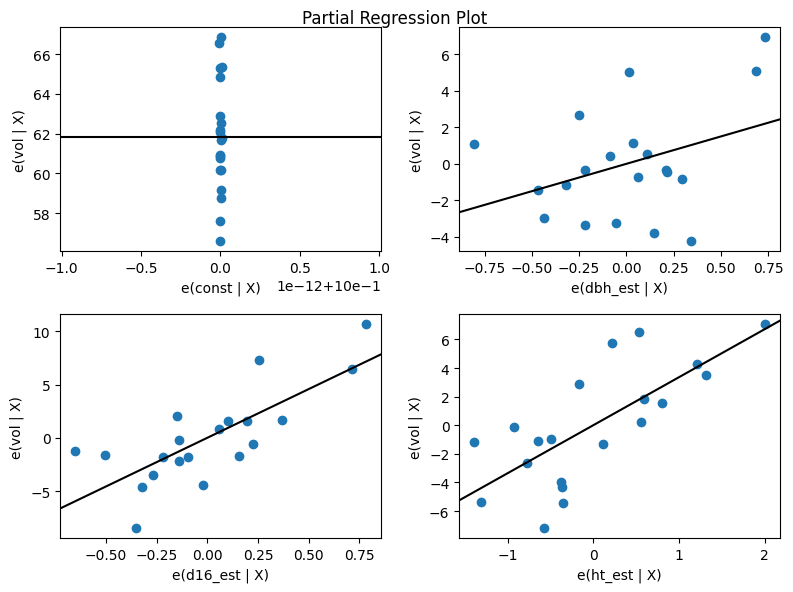

In [ ]:
from statsmodels.graphics.regressionplots import plot_partregress_grid

fig = plt.figure(figsize=(8, 6))
plot_partregress_grid(fit_bosque, fig=fig)
plt.show()

La nube de puntos que peor describe una tendencia lineal es la que proporciona la variable `dbh`, como ya se derivó del ajuste del modelo.

# <font color="steelblue">3. Bondad del ajuste</font>

La modelización de datos es siempre un trabajo tedioso debido a la innumerable cantidad de alternativas posibles. Hay que decidir el tipo de modelo, las transformaciones más adecuadas, las variables más relevantes, el descarte de las innecesarias, y siempre decidiendo sobre la bondad del ajuste, y validando finalmente una vez se realiza el diagnóstico del modelo, esto es, el cumplimiento de las hipótesis del modelo utilizado. El proceso de modelización acaba convirtiéndose en un ciclo en el que se repiten todos los pasos mencionados de modo iterativo, y que acaba cuando todos los resultados hablan a favor de mantener la última propuesta planteada.

En este cuaderno no saldremos del modelo de regresión múltiple, pero avanzaremos, paso a paso sobre las tareas que hemos de ir realizando en función de los resultados obtenidos.

Plantearemos pues como pasos a dar, los siguientes:
1. Ajustar un modelo (iniciamos con un modelo base, derivado del análisis exploratorio previo).

1. Valorar la bondad del ajuste, esto es, cuantificar cuánta de la variabilidad en los datos está siendo explicada por el modelo. Esto se resuelve con la Tabla de Anova, el test F de bondad de ajuste y los coeficientes de determinación.

1. Proceder con la selección de variables con la finalidad de simplificar al máximo el modelo sin perder capacidad predictiva.

1. Realizar el diagnóstico del modelo, es decir, verificar que se cumplen todas las hipótesis que avalan la fiabilidad de las inferencias en el modelo de regresión lineal múltiple. Resolver satisfactoriamente el diagnóstico implica validar el modelo.

Si en este proceso encontramos resultados no convincentes, habremos de volver al primer punto, revisar el modelo (quizás para plantear una modelización alternativa), y continuar con toda la secuencia de actuaciones de nuevo, hasta llegar a resultados satisfactorios. Una buena especificación del modelo es un trabajo, en general, complicado de obtener, y siempre se beneficia de la experiencia del analista.  

Puesto que en el apartado anterior ya hemos hablado de cómo ajustar un modelo de regresión lineal múltiple, abordamos a continuación comprobar la bondad del ajuste, esto es, cuantificar lo bueno que es el ajuste para predecir los datos observados. La bondad del ajuste la fundamentamos, básicamente, en el análisis de la varianza ANOVA, el test F de bondad de ajuste, y el coeficiente de determinación. Veamos cómo se calculan e interpretan estas medidas.



## Tabla ANOVA y test F

El análisis de la varianza, popularmente conocido como ANOVA, nos permite cuantificar de modo pormenorizado, cuanta variabilidad consiguen explicar cada una de las variables incluidas en el modelo, y compararlas con la variabilidad total para comprobar si aportan información significativa para explicar la respuesta.

Partiendo de las observaciones disponibles, $Y$, cuantificamos la variabilidad total que contienen a través de las distancias a las medias, o lo que es lo mismo, la **suma de cuadrados total SST**, esto es,

$$SST = (Y-\bar{y})'(Y-\bar{y}), $$

donde $\bar{y}$ representa la media muestral de los datos $Y$.

Puesto que el ajuste de regresión nos lo proporciona $\hat{~Y~} = X \hat{\beta~}$, la **suma de cuadrados debida a la regresión SSR** la obtenemos a través de las distancias a las medias:

$$SSR= (\hat{~Y~} - \bar{y})' (\hat{~Y~} - \bar{y}).$$

Por último, la **suma de cuadrados debida al error SSE**, cuantifica las distancias entre los datos observados y las predicciones que proporciona el modelo:

$$SSE= (Y-\hat{Y~})'(Y-\hat{Y~})=e'e$$

donde $e=Y-\hat{Y~}$ representa el error residual.

Tenemos pues, que la suma de cuadrados total SST la podemos expresar en función de SSR y SSE, descomponiendo pues la variabilidad en los datos en términos de la variabilidad explicada por el modelo SSR y la que no es capaz de explicar SSE:

$$ SST=SSE+SSR. $$



Una vez cuantificada la variabilidad con las sumas de cuadrados, hemos de vincular los grados de libertad asociados. Si $p$ representa el número de parámetros estimados en el modelo (con $p-1$ regresores o variables explicativas), entonces tenemos:

- SST tiene asociados $n-1$ grados de libertad al corregir el número de datos $n$ por la media (que aporta 1 g.l.).
- SSR tiene asociados $p-1$ grados de libertad por la pérdida de 1 g.l. al corregir por la media.
- SSE tiene asociados $n-p$ grados de libertad al restar el número de observaciones y el número de parámetros estimados en el modelo.

Obtenemos entonces las sumas medias de cuadrados, con $p$ parámetros en el modelo:
$$MST=\frac{SST}{n-1}; \quad MSR=\frac{SSR}{p-1}; \quad MSE=\frac{SSE}{n-p}.$$


De esta forma, la fracción que se genera el dividir el cuadrado medio de la regresión, MSR, entre el residual MSE, nos define el **estadístico F de la regresión**, que nos ayuda a valorar la **bondad del ajuste**:

$$
F = \frac{MSR}{MSE}
$$

De hecho, este estadístico, bajo la hipótesis nula de no efecto de los predictores (todos los coeficientes en el modelo son cero y por lo tanto ninguna de las variables predictoras explica variabilidad alguna de la respuesta):

$$
\left\lbrace\begin{array}{l} H_0: \beta_0=\beta_1 = \beta_2 = ... =\beta_{p-1} = 0 \\ H_1: \text{al menos algún } \beta_j \neq 0 \end{array}\right.
$$

sigue una distribución F de Snedecor con $p-1$ y $n-p$ grados de libertad, al obtenerse del cociente de dos estadísticos independientes con distribuciones Chi-cuadrado:

$$ \text{ Bajo } H_0 \rightarrow F \sim F_{p-1,n-p}$$

Cuando el estadístico $F$ obtiene un valor extrañamente alto en la muestra observada, estamos afirmando que la variabilidad explicada por el modelo es muy alta comparada con la que queda sin explicar, lo que habla a favor del modelo. Calculamos, para evaluar si efectivamente es suficiente -o **significativamente**- grande, el **p-valor** asociado:

$$p-valor = Pr(F_{p-1,~n-p}>F)$$

Si dicho p-valor es muy pequeño, significa que es muy poco probable observar un valor tan extremo cuando $H_0$ es cierto, lo que da evidencias en contra de esta hipótesis, y a favor de la alternativa, esto es, de que las predictivas (al menos alguna) sí son útiles para explicar la respuesta (o equivalentemente, algún coeficiente es distinto de cero).

Así, utilizamos habitualmente como regla de salto el valor de significatividad de 0.05, que nos permite reconocer si un modelo es significativo al nivel de confianza del 95%, es decir, si alguna de las variables en el modelo contiene información significativa para predecir la respuesta:

$$\text{Si } p-valor < 0.05 \Rightarrow \text{ rechazo } H_0 \text{ a favor de } H_1.$$

Cuando $p-valor \geq \alpha$, no tendremos evidencias suficientes para reconocer la bondad del modelo ajustado, lo que no significa que aceptemos $H_0$.


La información completa sobre cómo se descompone la varianza total en los datos se muestra en lo que se conoce como **tabla de ANOVA** del modelo (ver Tabla 1). Esta tabla muestra información de las sumas de cuadrados SSR y grados de libertad, junto con el estadístico F y su p-valor.

SS | g.l. | MS | F |     pvalor             |
- | -- |  -- |  -- |    ---------      |
SSR | p-1 | MSR | F= MSR/MSE| $Pr(F_{p-1,n-p}>F)$|
SSE | n-p |MSE |  | ......................................|
SST | n-1 | MST |  | |

**Tabla 1:** *Tabla de ANOVA para el modelo de regresión múltiple ($p$ parámetros a estimar, con $p-1$ predictores).*


En la práctica, habitualmente todos los programas informáticos proporcionan una tabla de ANOVA secuencial en la que se incorporan una a una todas las predictoras, y para cada una de ellas una cuantificación de la suma de cuadrados con la que contribuye a explicar la varianza respecto a cómo se explicaba con el modelo previo en el que ya se habían introducido las anteriores (ver Tabla 2). Para cada una de estas sumas de cuadrados se calcula un estadístico F y un p-valor con el que se valora si la variable en cuestión aporta explicación al modelo previo (con las variables ya incorporadas) de modo significativo. Si el p-valor es significativo ($pvalor<0.05$), se concluye que la variable es significativa para explicar la respuesta en presencia de las predictoras previamente incorporadas. El modo de calcular los estadísticos F asociados a cada variable viene pues condicionado por el orden en el que se introducen las variables en el modelo, lo que influye decisivamente sobre los resultados y las conclusiones que se derivan, y por lo que han de interpretarse con cautela los p-valores correspondientes.


Variable | SS | g.l. | MS | F | p-valor |
- |-- | -- |  -- |  -- |  -- |
 ||  |   |  .................................... |  ........................................ |
$X_1$ | SSR_1 | 1 | MSR_1 | $F_1=\frac{SST-SSE_2}{SST/(n-1)}$ | $Pr(F_{1,n-1}>F_1)$ |
$X_2$ | SSR_2 | 1 | MSR_2 | $F_2=\frac{SSE_1-SSE_2}{SSE_1/(n-2)}$ | $Pr(F_{1,n-2}>F_2)$ |
...|...|...|...|...|...|
$X_j$ | SSR_j | 1 | MSR_j | $F_j=\frac{SSE_{j-1}-SSE_j}{SSE_{j-1}/(n-j)}$ | $Pr(F_{1,n-j}>F_j)$ |
...|...|...|...|...|...|
Error | SSE | n-p| MST |  | |

**Tabla 2:** *Tabla de ANOVA con la contribución secuencial de los $p-1$ predictores en el modelo de regresión múltiple.*

## ANOVA con Python

En Python el estadístico $F$ y el p-valor asociado a la bondad del modelo global se muestran en el descriptivo del modelo que obtenemos con `model.summary()`, en los valores de *F-statistic* y *Prob (F-statistic)*.

Para conseguir la tabla ANOVA en Python con la aportación secuencial de todos los predictores, utilizamos la función **[`anova_lm`](https://www.statsmodels.org/dev/generated/statsmodels.stats.anova.anova_lm.html)** del módulo `statsmodels.stats.anova`, aplicada al modelo ajustado. Ahora bien, puesto que el orden de introducción de los predictores afecta a los cálculos de los estadísticos F y sus p-valores en la tabla de ANOVA, es preciso reajustar el modelo con un orden específico para los predictores, que se consigue a través de una formulación del modelo.

Por otro lado, para obtener directamente el p-valor del test F asociado a la bondad del ajuste, podemos añadir  la extensión **`.f_pvalue`** al modelo ajustado, utilicemos la formulación matricial o la fórmula de la regresión.

La sintaxis a utilizar es la siguiente:

```
# importamos los módulos
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Ajustamos el modelo con su fórmula de regresión
model = sm.OLS('respuesta ~ x1 + x2+ ...',data=df).fit()

# Varianzas asociadas al modelo
model.mse_model
model.mse_total
model.mse_resid
# equivalente a
model.scale

# Estadístico F y pvalor
model.fvalue
model.f_pvalue
model.summary()

# obtenemos la tabla de anova
table = sm.stats.anova_lm(model)
# y la mostramos
print(table)

```




Importamos las funciones relevantes y obtenemos las tablas de ANOVA en los ejemplos anteriores.


In [ ]:
# carga de módulos
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

### Ejemplo 1. Papel

Reajustamos ahora el modelo lineal utilizando la formulación de la regresión, y comprobamos que el test F que se obtiene en la tabla de ANOVA se corresponde con el estadístico F del modelo, al tener este una única predictora.


In [ ]:
# Ajuste del Modelo (a partir de las variables separadas)
fit_papel2 = smf.ols('tension ~ conc', data = papel).fit()
# Tabla ANOVA
anova_lm(fit_papel2)

,df,sum_sq,mean_sq,F,PR(>F)
conc,1.0,1043.427434,1043.427434,7.473597,0.01414
Residual,17.0,2373.457829,139.615166,NaN,NaN


Verificamos que efectivamente el test F del modelo con un solo regresor es el que proporciona la tabla de ANOVA.

In [ ]:
# calculamos el p-valor del estadístico F del modelo que ya ajustamos
print('El p-valor para el contraste de la bondad del ajuste es {:,.2e}'.format(fit_papel.f_pvalue))
# comprobando que sale idéntico para este segundo ajuste con la fórmula
print('El p-valor para el contraste de la bondad del ajuste es {:,.2e}'.format(fit_papel2.f_pvalue))

El p-valor para el contraste de la bondad del ajuste es 1.41e-02
El p-valor para el contraste de la bondad del ajuste es 1.41e-02


Al obtener un resultado significativo para la bondad del ajuste, podemos asumir cierta capacidad explicativa del modelo (no lo rechazamos para explicar la respuesta), pero habremos de considerar otras medidas de bondad de ajuste que saquen a la luz el comportamiento errático en la tendencia que hemos apreciado en el gráfico.

### Ejemplo 2. Madera

Con el modelo que ya ajustamos, valoramos la significatividad global del modelo asociada al estadístico F. Efectivamente resulta significativo.

In [ ]:
# p-valor F del modelo ajustado
fit_bosque.f_pvalue

2.587203717262769e-11

Ahora bien, al tener varios predictores en el modelo, este resultado no se va a corresponder con los estadísticos F y los p-valores asociados a la introducción secuencial de los mismos que se visualiza en la tabla de ANOVA a continuación.

In [ ]:
# Especificacón del Modelo con su fórmula de regresión
fit_bosque2 = smf.ols('vol ~ dbh + d16 + ht', data = bosque).fit()
# Tabla ANOVA
anova_lm(fit_bosque2)

,df,sum_sq,mean_sq,F,PR(>F)
dbh,1.0,3085.788749,3085.788749,322.063868,5.051326e-12
d16,1.0,331.851120,331.851120,34.635312,2.303165e-05
ht,1.0,173.417875,173.417875,18.099629,6.056469e-04
Residual,16.0,153.300711,9.581294,NaN,NaN


Los efectos inviduales de cada predictora resultan significativos, lo que indica que secuencialmente añaden información para predecir la respuesta.

Globalmente el F de la bondad del ajuste para la regresión, que calculamos previamente, no coincide con ninguno de los p-valores que se visualizan en esta tabla de ANOVA, por el modo en que se calculan.

Si variamos el orden de los predictores en la formulación del modelo, los p-valores cambian, y alguno de ellos podría resultar no significativo. Veámoslo.

In [ ]:
# Especificacón del Modelo con otro orden de introducción de predictores
fit_bosque2 = smf.ols('vol ~  d16 + dbh +ht', data = bosque).fit()
# Tabla ANOVA
anova_lm(fit_bosque2)

,df,sum_sq,mean_sq,F,PR(>F)
d16,1.0,3401.347263,3401.347263,354.998720,2.396462e-12
dbh,1.0,16.292606,16.292606,1.700460,2.106773e-01
ht,1.0,173.417875,173.417875,18.099629,6.056469e-04
Residual,16.0,153.300711,9.581294,NaN,NaN


Y observamos en esta segunda formulación que la variable `dbh`, una vez ya introducida la variable `d16` en el modelo, no resulta significativa para explicar la respuesta, si bien en el modelo anterior sí lo era al introducirla la primera.

En cualquier caso, el estadístico F de bondad del ajuste da resultados similares independientemente del orden de las predictoras en el modelo:

In [ ]:
# Test F
print('El p-valor para el contraste de la bondad del ajuste es {:,.2e}'.format(fit_bosque.f_pvalue))
print('El p-valor para el contraste de la bondad del ajuste es {:,.2e}'.format(fit_bosque2.f_pvalue))

El p-valor para el contraste de la bondad del ajuste es 2.59e-11
El p-valor para el contraste de la bondad del ajuste es 2.59e-11


# <font color="steelblue">4. Comparación y selección de modelos</font>

Una vez hemos ajustado un modelo de regresión múltiple con los predictores disponibles, y al que nos referiremos como **modelo basal**, surge la cuestión de plantear si realmente todos esos predictores son importantes para predecir la respuesta, o bien es posible prescindir de alguno que no guarde relación alguna con la respuesta, o simplemente que no aporte información adicional respecto de la que ya aportan los otros predictores. El objetivo final es simplificar el modelo al máximo manteniendo una buena calidad predictiva (sabemos que reducir el número de predictores incrementa el error cuadrático medio MSE), por lo que habremos de llegar a un compromiso "razonable" entre la complejidad/simplicidad del modelo y el error que comete en la predicción. Esta dinámica la reconocemos como **procedimiento de selección de variables**.


Para abordar esta tarea debemos introducir algunos conceptos habituales que utilizaremos:

* **Modelo saturado**: es aquel que contiene tantos parámetros como datos disponibles, de modo que proporciona un ajuste perfecto de los datos observados.  

* **Modelo basal**: es el modelo del que partimos al iniciar el análisis.

* **Modelos anidados**: son todos los modelos alternativos con un menor número de predictores (que de datos), y que por lo tanto se pueden considerar "anidados" dentro del modelo saturado, pues proporcionan menos información sobre la respuesta.


La selección de variables la vamos a resolver como un problema de **comparación de modelos**. Realmente, decidir si una variable es relevante o no para predecir una respuesta, lo podemos equiparar a comparar un modelo en el que predecimos con ella y otro en el que la obviamos, manteniendo igual el resto de predictores. Una vez sabemos bien cómo comparamos un modelo con cierta variable frente a otro sin ella, podemos plantear diferentes **estrategias de selección** hacia adelante o hacia atrás, añadiendo o quitando variables en diferente orden, para llegar a un modelo óptimo desde el punto de vista predictivo, pero a la par con el menor número de predictores posibles, al excluir variables que aportan información redundante.

Cabe mencionar que, si una variable se excluye del modelo como predictor, significa que no añade información adicional, aunque sí esté relacionada con la variable respuesta.

## Comparación de modelos

Veamos pues, cómo proceder para resolver la comparación de dos modelos, y decidir con ello cuál de los dos es preferible. Para llevarlo a cabo podemos utilizar diversos criterios alternativos que, no siempre proporcionan conclusiones similares. Habremos pues de decidir también qué criterio de comparación utilizar, en función de cuáles son los intereses prioritarios (simplificar al máximo el modelo, predecir lo mejor posible, ...).

Los criterios de comparación más habituales son los siguientes:

* Basados en la **significatividad de los predictores** para explicar la respuesta.

* Basados en unos estadísticos que tienen en cuenta la **verosimilitud** (para maximizarla), penalizándola por la **complejidad del modelo** (o número de parámetros/predictores). Se conocen como **criterios de información**, y lo más populares y habituales son el $AIC$ (*Akaike Information Criteria*) y el $BIC$ (*Bayesian Information Criteria*).

Existen otros muchos criterios de comparación de modelos, como el $C_p$ de Mallows, el $R^2$ ajustado, etc., que no vamos a utilizar qeuí.

Veamos en detalle cómo utilizar los dos modos de comparación presentados para seleccionar el mejor modelo.

### Ejemplo 2. Madera

Pasamos a aplicar estos nuevos conocimientos al ejemplo de Madera, donde contamos con varios predictores, alguno de los cuales resultaba sospechoso con un p-valor no significativo en la tabla de Anova.

Vamos a comparar pues, el modelo basal ajustado con todos los predictores, con otro en el que vamos a excluir la variable `dbh`, pues parecía ser la que menos relación guarda con la respuesta.

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
# Creamos conjunto de datos con respuesta y las predictoras (originales y estandarizadas)
bosque_comp = pd.concat([Y_bosque, X_bosque], axis = 1)

# modelo basal con todas las variables
basal= smf.ols('vol ~ dbh_est + d16_est + ht_est', data = bosque_comp).fit()
# modelo anidado
anidado = smf.ols('vol ~ d16_est + ht_est', data = bosque_comp).fit()
# comparación
tabla = anova_lm(anidado, basal)
tabla.index = ['Anidado', 'Basal']
tabla

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
Anidado,17.0,177.360280,0.0,NaN,NaN,NaN
Basal,16.0,153.300711,1.0,24.059569,2.511098,0.132611


Obtenemos un p-valor de 0.1326, que no es significativo, lo que NO nos da evidencias para incorporar significativamente la variable `dbh` y así mejorar la capacidad explicativa del modelo, o lo que es lo mismo, nos lleva a NO rechazar el modelo más sencillo con sólo dos variables. Concluiremos que sólo las variables `d16` y `ht` son suficientes para explicar el comportamiento de la respuesta, y `dbh` es prescindible.

 Podríamos haber conseguido idénticos resultados si aprovechamos el carácter secuencial en la tabla de ANOVA de un modelo. Si ajustamos el modelo basal incorporando en último lugar la variable `dbh`, el test F asociado a esta variable en la tabla de ANOVA es justamente el test F de comparación de los dos modelos que hemos planteado. Comprobémoslo.

In [ ]:
# modelo basal, incorporando dbh en último lugar
basal = smf.ols('vol ~  d16_est + ht_est + dbh_est', data = bosque_comp).fit()
# tabla de anova para el modelo basal
tabla = anova_lm(basal)
tabla

,df,sum_sq,mean_sq,F,PR(>F)
d16_est,1.0,3401.347263,3401.347263,354.998720,2.396462e-12
ht_est,1.0,165.650912,165.650912,17.288991,7.408142e-04
dbh_est,1.0,24.059569,24.059569,2.511098,1.326107e-01
Residual,16.0,153.300711,9.581294,NaN,NaN


Efectivamente, el estadístico F asociado a `dbh` es 2.51 y el p-valor asociado es 0.1326, como calculamos antes.

### Criterios de información

El **Criterio de Información de Akaike (AIC)** está basado en la función de verosimilitud que presentamos al principio del cuaderno e incluye una penalización que va aumentando conforme lo hace el número de parámetros estimados en el modelo. De esta manera se 'premia' a los modelos que dan un buen ajuste en términos de verosimilitud y a la vez son parsimoniosos, es decir, que tienen pocos parámetros. El BIC cambia el valor $2p$ por $log(n)p$ para evalaur con mayor precisión los conjunto de datos con pocos datos.

### Criterios de información con Python

Se calculan aplicando los métodos `aic` y `bic` al modelo ajustado. La logverosimilitud se consigue con `llf`.
```
# aic
model.aic

# bic
model.bic
```




### Ejemplo 2. Madera

Veamos cómo opera con los dos modelos que acabamos de comparar en los datos de Madera, para valorar si prescindir de la variable `dbh`.

In [ ]:
# AIC
print('El AIC para el modelo basal es {:,.4f}'.format(basal.aic))
print('El AIC para el modelo anidado, sin dbh, es {:,.4f}'.format(anidado.aic))

El AIC para el modelo basal es 105.4909
El AIC para el modelo anidado, sin dbh, es 106.4066


Así, en base al criterio AIC no prescindiríamos de la variable `dbh`. Veamos con EL BIC.

In [ ]:
# BIC
print('El BIC para el modelo basal es {:,.4f}'.format(basal.bic))
print('El BIC para el modelo anidado, sin dbh, es {:,.4f}'.format(anidado.bic))

El BIC para el modelo basal es 109.4739
El BIC para el modelo anidado, sin dbh, es 109.3938


Con el criterio BIC, sin embargo, la recomendación sería prescindir de la variable `dbh` y mantener el modelo de predicción sólo con dos variables. La diferencia entre los valores BIC es muy leve, lo que habla a favor de lo poco que aporta la variable `dbh`.

## Estrategias de selección



Una vez tenemos claro cómo podemos comparar dos modelos cualesquiera, cabe plantear una estrategia de búsqueda de un modelo óptimo en el sentido de asegurar máxima capacidad explicativa y a la par máxima simplicidad, y a ser posible, que realice la selección óptima de modo automático.

En la literatura encontramos diversos procedimientos automáticos de selección de variables que nos resultan francamente útiles cuando el número de predictores es grande, dada la gran cantidad de alternativas de comparación que surgen en función del orden de introducción de los predictores. Para dicha selección automática se puede optar por cualquiera de los criterios de selección presentados en el apartado anterior, esto es, basados en significatividad del test F, o en criterios de información (entre otros).

Podemos diferenciar básicamente tres estrategias de búsqueda del modelo óptimo, que se aplican una vez elegido un criterio de comparación de modelos determinado para valorar cuál es mejor:

**Estrategia forward o hacia adelante**: Se parte de un modelo basal sin predictores (el único parámetro estimado es una gran media representada en $\beta_0$). A partir de él se construyen todos los posibles modelos con una sola predictora de entre las disponibles. Se fija el predictor que ofrece un "mejor ajuste" al compararlo con el modelo basal. A continuación se intenta incrementar la complejidad del modelo añadiendo una de las predictoras restantes, e igualmente se construyen todos los modelos con dos predictores, la fijada en el primer paso y cada una de las restantes, y se fija un segundo predictor con aquella variable que proporciona el mejor ajuste de entre todos los considerados.
Este proceso se repite sucesivamente incorporando predictores hasta llegar al punto en el que ninguna de las variables predictoras que quedan por incorporar mejora el modelo previo.

**Estrategia backward o hacia atrás**: El proceso se inicia con el modelo basal en el que se integran todas las variables predictoras. Se construyen todos los modelos con una predictora menos y se selecciona aquel que proporciona un mejor ajuste según el criterio elegido al compararlo con el modelo basal. Se sigue con el proceso sucesivamente hasta que eliminar cualquiera de las variables que quedan en el modelo no mejora el ajuste previo según el criterio elegido.


**Estrategia Stepwise o paso a paso**: Se trata de una combinación de la selección *forward* y *backward*. Se inicia igual que el procedimiento *forward*, partiendo de un modelo basal sin predictoras, pero tras cada nueva incorporación de un predictor se realiza un test de extracción *backward* para desechar los predictores no útiles. Presenta la ventaja de que, si a medida que se añaden predictores, alguno de los ya presentes deja de contribuir al modelo, se elimina.

A continuación se ofrecen algunas funciones ya elaboradas por otros autores, y no disponibles en la librería Statsmodels, para realizar la selección automática de predictores.

In [ ]:
# Funciones de selección forward y backward para modelos lineales de statsmodels
# Reutilizada de https://cienciadedatos.net/documentos/py10b-regresion-lineal-multiple-python,
# web mantenida por Joaquín Amat [CC BY-NC-SA]
# ==============================================================================

def forward_selection(
    X: pd.DataFrame,
    y: pd.Series,
    criterio: str='aic',
    add_constant: bool=True,
    verbose: bool=True
)-> list:

    """
    Realiza un procedimiento de selección de variables hacia adelante (forward)
    utilizando como criterio de bondad la métrica especificada. El procedimiento
    se detiene cuando no es posible mejorar más el modelo añadiendo variables.

    Parameters
    ----------
    X: pd.DataFrame
        Matriz de predictores
    y: pd.Series
        Variable respuesta
    metrica: str, default='aic'
        Métrica utilizada para seleccionar las variables. Debe ser una de las
        siguientes opciones: 'aic', 'bic', 'rsquared_adj'.
    add_constant: bool, default=True
        Si `True` añade una columna de 1s a la matriz de predictores con el
        con el nombre de intercept.
    verbose: bool, default=True
        Si `True` muestra por pantalla los resultados de cada iteración.

    Returns
    -------
    seleccion: list
        Lista con las variables seleccionadas.
    """

    if add_constant:
        X = sm.add_constant(X, prepend=True).rename(columns={'const':'intercept'})

    restantes = X.columns.to_list()
    seleccion = []
    if criterio == 'rsquared_adj':
        mejor_metrica = -np.inf
        ultima_metrica = -np.inf
    else:
        mejor_metrica = np.inf
        ultima_metrica = np.inf

    while restantes:
        metricas = []
        for candidata in restantes:
            seleccion_temp = seleccion + [candidata]
            modelo  = sm.OLS(endog=y, exog=X[seleccion_temp])
            modelo_res = modelo.fit()
            metrica = getattr(modelo_res, criterio)
            metricas.append(metrica)
        if criterio == 'rsquared_adj':
            mejor_metrica = max(metricas)
            if mejor_metrica > ultima_metrica:
                mejor_variable = restantes[np.argmax(metricas)]
            else:
                break
        else:
            mejor_metrica = min(metricas)
            if mejor_metrica < ultima_metrica:
                mejor_variable = restantes[np.argmin(metricas)]
            else:
                break

        seleccion.append(mejor_variable)
        restantes.remove(mejor_variable)
        ultima_metrica = mejor_metrica

        if verbose:
            print(f'variables: {seleccion} | {criterio}: {mejor_metrica:.3f}')

    return sorted(seleccion)


def backward_selection(
    X: pd.DataFrame,
    y: pd.Series,
    criterio: str='aic',
    add_constant: bool=True,
    verbose: bool=True
)-> list:

    """
    Realiza un procedimiento de selección de variables hacia atrás (backward)
    utilizando como criterio de bondad la métrica especificada. El procedimiento
    se detiene cuando no es posible mejorar más el modelo eliminando variables.

    Parameters
    ----------
    X: pd.DataFrame
        Matriz de predictores
    y: pd.Series
        Variable respuesta
    metrica: str, default='aic'
        Métrica utilizada para seleccionar las variables. Debe ser una de las
        siguientes opciones: 'aic', 'bic', 'rsquared_adj'.
    add_constant: bool, default=True
        Si `True` añade una columna de 1s a la matriz de predictores con el
        con el nombre de intercept.
    verbose: bool, default=True
        Si `True` muestra por pantalla los resultados de cada iteración.

    Returns
    -------
    seleccion: list
        Lista con las variables seleccionadas.
    """

    if add_constant:
        X = sm.add_constant(X, prepend=True).rename(columns={'const':'intercept'})

    # Se inicia con todas las variables como predictores
    seleccion = X.columns.to_list()
    modelo  = sm.OLS(endog=y, exog=X[seleccion])
    modelo_res = modelo.fit()
    ultima_metrica = getattr(modelo_res, criterio)
    mejor_metrica = ultima_metrica
    if verbose:
            print(f'variables: {seleccion} | {criterio}: {mejor_metrica:.3f}')

    while seleccion:
        metricas = []
        for candidata in seleccion:
            seleccion_temp = seleccion.copy()
            seleccion_temp.remove(candidata)
            modelo  = sm.OLS(endog=y, exog=X[seleccion_temp])
            modelo_res = modelo.fit()
            metrica = getattr(modelo_res, criterio)
            metricas.append(metrica)
        if criterio == 'rsquared_adj':
            mejor_metrica = max(metricas)
            if mejor_metrica > ultima_metrica:
                peor_variable = seleccion[np.argmax(metricas)]
            else:
                break
        else:
            mejor_metrica = min(metricas)
            if mejor_metrica < ultima_metrica:
                peor_variable = seleccion[np.argmin(metricas)]
            else:
                break

        seleccion.remove(peor_variable)
        ultima_metrica = mejor_metrica

        if verbose:
            print(f'variables: {seleccion} | {criterio}: {mejor_metrica:.3f}')

    return sorted(seleccion)

## Ejemplo 2. Madera

Veamos el funcionamiento de ambas funciones sobre el conjunto de datos de producción de madera. Comenzamos con el procedimiento forward utilizando la matriz de diseño con las variables estandarizadas:

In [ ]:
# Selección forward con criterio AIC
var_forw_aic = forward_selection(
    X            = Xest_bosque,
    y            = Y_bosque,
    criterio     = 'aic',
    add_constant = False,
    verbose      = True
)
print("\n Efectos seleccionados:", var_forw_aic)

variables: ['const'] | aic: 163.403
variables: ['const', 'd16_est'] | aic: 117.598
variables: ['const', 'd16_est', 'ht_est'] | aic: 106.407
variables: ['const', 'd16_est', 'ht_est', 'dbh_est'] | aic: 105.491

 Efectos seleccionados: ['const', 'd16_est', 'dbh_est', 'ht_est']


Se muestran en el resultado, los sucesivos modelos que se construyen a partir del modelo con sólo interceptación. Se aprecia cómo el valor del `AIC` disminuye conforme se incorporan más variables al modelo, hasta incorporar las tres.

Repetimos la selección utilizando la misma estrategia, pero ahora con el criterio de comparación basado en el `BIC`.

In [ ]:
# Selección forward con criterio BIC
var_forw_bic = forward_selection(
    X            = Xest_bosque,
    y            = Y_bosque,
    criterio     = 'bic',
    add_constant = False,
    verbose      = True
)
print("\n Efectos seleccionados:", var_forw_bic)

variables: ['const'] | bic: 164.399
variables: ['const', 'd16_est'] | bic: 119.590
variables: ['const', 'd16_est', 'ht_est'] | bic: 109.394

 Efectos seleccionados: ['const', 'd16_est', 'ht_est']


En este caso el modelo final sólo contiene las predictoras `d16` y `ht`, y prescinde de la `dbh`.

Probemos qué ocurre ahora con el procedimiento *backward*.

In [ ]:
# Selección backward con criterio AIC

var_back_aic= backward_selection(
    X            = Xest_bosque,
    y            = Y_bosque,
    criterio     = 'aic',
    add_constant = False, # Ya se le añadió anteriormente
    verbose      = True
)
print("\n Efectos seleccionados:", var_back_aic)

variables: ['const', 'dbh_est', 'd16_est', 'ht_est'] | aic: 105.491

 Efectos seleccionados: ['const', 'd16_est', 'dbh_est', 'ht_est']


Al partir del modelo completo con todos los predictores, no consigue excluir ninguno con el criterio `AIC`. Es de esperar que sí consiga excluir `dbh` con el criterio `BIC`; veámoslo.

In [ ]:
# Selección backward con criterio BIC
var_back_bic= backward_selection(
    X            = Xest_bosque,
    y            = Y_bosque,
    criterio     = 'bic',
    add_constant = False, # Ya se le añadió anteriormente
    verbose      = True
)
print("\n Efectos seleccionados:", var_back_bic)

variables: ['const', 'dbh_est', 'd16_est', 'ht_est'] | bic: 109.474
variables: ['const', 'd16_est', 'ht_est'] | bic: 109.394

 Efectos seleccionados: ['const', 'd16_est', 'ht_est']


Y efectivamente es lo que obtenemos. Conseguimos pues, llegar al mismo modelo utilizando tanto el procedimiento forward, como el backward, para un criterio de selección dado.

Si finalmente optamos por priorizar modelos más sencillos, justificamos la utilización del criterio BIC. Reajustamos pues el modelo con los dos predictores seleccionados, y lo utilizamos como modelo de predicción con el que proseguir con el diagnóstico y validación del modelo.

In [ ]:
# Reajuste del modelo con 2 predictores
fit_bosque_final  = sm.OLS(Y_bosque, Xest_bosque[var_back_bic]).fit()
print(fit_bosque_final.summary())

                            OLS Regression Results                            
Dep. Variable:                    vol   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     170.9
Date:                Thu, 27 Feb 2025   Prob (F-statistic):           5.52e-12
Time:                        10:42:16   Log-Likelihood:                -50.203
No. Observations:                  20   AIC:                             106.4
Df Residuals:                      17   BIC:                             109.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.8515      0.722     85.637      0.0

El modelo resultante viene dado por la expresión:

$$\widehat{vol} = 61.8515 + 11.9670 \cdot d16_e + 3.2733 \cdot ht_e$$

donde `d16` es la predictora más relevante (con un coeficiente mayor en el modelo estandarizado), de forma que una aumento de una unidad en la variable estandarizada provoca un incremento de 11.97 unidades en el volumen de madera recogido.

# <font color="steelblue">5. Predicción</font>

Una vez obtenido un modelo definitivo, la última fase de la modelización consiste en la predicción de la respuesta a partir de un nuevo conjunto de valores de la predictora o predictoras. Básicamente se trata de utilizar valores de los predictores en los rangos observados, para predecir el valor de la respuesta sin observarlo.

Si $X_0 \in \mathbb{R}^p$ representa un vector fijo de valores de las variables explicativas contenidas en la matriz de diseño $X$, podemos predecir la respuesta $y$ en $X_0$ a través del modelo ajustado con:

$$
\hat{y}=X_0 \hat{~\beta~~}
$$

Para calcular el error asociado a la estimación consideramos dos situaciones:
- pretendemos predecir la respuesta media o esperada para los valores observados
- pretendemos predecir nuevas observaciones que no tenemos en la muestra de ajuste.



## Predicción con Python

Para las predicciones planteadas a partir de un modelo RLM ajustado hemos de crear una matriz de diseño con los datos de los predictores a utilizar en la predicción, estandarizarlos y usar la función `get_prediction()`. Con el método `summary_frame(alpha=0.05)` conseguimos visualizar todas las prediccionesal nivel de significatividad especificado, tanto para la respuesta media como para una futura predicción.

En esta dataframe de predicciones, las columnas `mean_ci_lower` y `mean_ci_upper` representan el intervalo de confianza al 95% para la predicción de la media, mientras que las columnas `obs_ci_lower` y `obs_ci_upper` son el intervalo de confianza al 95% para la predicción de una futura observación.

```
# X0 matriz de diseño con los valores de los predictores a utilizar
# obtenemos todas las predicciones e intervalos de confianza
predicciones = model.get_prediction(exog=X0).summary_frame(alpha=0.05)

# representación de la predicción media para un predictor x
# puntos con los datos originales
plot(df['x'],df['y'],'o')
# línea con los datos predichos
plot(predicciones['x'], predicciones["mean"], color="red")
# intervalo de confianza
fill_between(predicciones['x'], predicciones["mean_ci_lower"], predicciones["mean_ci_upper"], color="moccasin")

# representación de la predicción de una futura observación para un predictor x
# puntos con los datos originales
plot(df['x'],df['y'],'o')
# línea con los datos predichos
plot(predicciones['x'], predicciones["mean"], color="red")
# intervalo de confianza
fill_between(predicciones['x'], predicciones["obs_ci_lower"], predicciones["obs_ci_upper"], color="moccasin")
```



## Ejemplo 1. Papel

En este caso el modelo contiene realmente una única predictora, que se utiliza de modo lineal y cuadrático con su cuadrado. Calculamos pues la matriz $X_0$ con la que predecir, estandarizando una secuencia de valores de la variable `conc` en el rango de las observaciones disponibles, y también su cuadrado.

In [ ]:
# Ajuste del modelo
fit_papel = sm.OLS(Y_papel, X_papel).fit()

Concentration = 5.35

# Calculamos el cuadrado
Concentration2 = Concentration*Concentration

### Estandarización
# estandarizamos las variables con la media y sd de los datos originales
est_conc = (Concentration - X_papel['conc'].mean())/X_papel['conc'].std()
est_conc2 = (Concentration2 - X_papel['conc2'].mean())/X_papel['conc2'].std()

# Construimos el dataframe X0 para predecir

valorpred = [1, est_conc, est_conc2]
X0= pd.DataFrame(valorpred, index=[['const', 'conc', 'conc2']]).T

### Predicción
# Obtenemos la tabla de predicciones con un nivel de significatividad alpha
predicciones = fit_papel.get_prediction(exog=X0).summary_frame(alpha=0.05)

# predicción media
predone = 'La predicción de la tensión media del papel para una concentración de %4.2f es de %4.2f con intervalo de confianza de [%4.2f, %4.2f]'%(Concentration, predicciones["mean"][0], predicciones["mean_ci_lower"][0], predicciones["mean_ci_upper"][0])
print(predone)
# predicción de una observación
predone = 'La predicción de la tensión del papel para una concentración de %4.2f es de %4.2f con intervalo de confianza de [%4.2f, %4.2f]'%(Concentration, predicciones["mean"][0], predicciones["obs_ci_lower"][0], predicciones["obs_ci_upper"][0])
print(predone)


La predicción de la tensión media del papel para una concentración de 8.40 es de 47.37 con intervalo de confianza de [44.16, 50.58]
La predicción de la tensión del papel para una concentración de 8.40 es de 47.37 con intervalo de confianza de [37.47, 57.27]


## Ejemplo 2. Madera


Calculamos la matriz  $𝑋_0$  con la que predecir, estandarizando los valores, a partir de secuencias de valores para todos los predictores en el rango de variación observado.


In [ ]:
Xest_bosque2 = Xest_bosque[['d16', 'ht']]
# Ajuste del modelo
fit_bosque = sm.OLS(Y_bosque, Xest_bosque2).fit()

d16 = 15.3
ht = 94.7

### Estandarización
est_d16 = (d16 - X_bosque['d16'].mean())/X_bosque['d16'].std()
est_ht = (ht - X_bosque['ht'].mean())/X_bosque['ht'].std()

# Construimos el dataframe X0 para predecir

valorpred = [1, est_d16, est_ht]
X0 = pd.DataFrame(valorpred, index=[['const', 'd16_est','ht_est']]).T

### Predicción
# Obtenemos la tabla de predicciones con un nivel de significatividad alpha
predicciones = fit_bosque.get_prediction(exog=X0).summary_frame(alpha=0.05)
# predicción media
predone = 'La predicción del volumen medio de madera es de %4.2f con intervalo de confianza de [%4.2f, %4.2f]'%(predicciones["mean"][0], predicciones["mean_ci_lower"][0], predicciones["mean_ci_upper"][0])
print(predone)
# predicción de una observación
predone = 'La predicción del volumen de madera es de %4.2f con intervalo de confianza de [%4.2f, %4.2f]'%(predicciones["mean"][0], predicciones["obs_ci_lower"][0], predicciones["obs_ci_upper"][0])
print(predone)


La predicción del volumen medio de madera es de 71.58 con intervalo de confianza de [69.34, 73.83]
La predicción del volumen de madera es de 71.58 con intervalo de confianza de [64.41, 78.76]


# <font color="steelblue">6. Ejercicios</font>

## **Ejercicio 1**

Se ha realizado un experimento para tratar de conocer la viscosidad de cierto compuesto en función de la cantidad de un tipo de aceite que se usa en su fabricación. Se asume una relación de tipo lineal entre la viscosidad y la cantidad de aceite utilizada.

In [ ]:
# Ejercicio 1
aceite = [0, 12, 24, 36, 48, 60, 0, 12, 24, 36, 48, 60, 0, 12, 24,
            36, 48, 60, 12, 24, 36, 48, 60]
viscosidad = [6, 38, 50, 76, 108, 157, 17, 26, 37, 53, 83, 124, 13,
                20, 27, 37, 57, 87, 15, 22, 27, 41, 63]
# Dataframe
ejer01 = pd.DataFrame({"aceite": aceite, "viscosidad": viscosidad})
ejer01.head()

,aceite,viscosidad
0,0,6
1,12,38
2,24,50
3,36,76
4,48,108


## **Ejercicio 2**

Los datos muestran el porcentaje de calorías totales obtenidas de carbohidratos complejos, para veinte diabéticos dependientes de insulina que habían seguido una dieta alta en carbohidratos durante seis meses. Se consideró que el cumplimiento del régimen estaba relacionado con la edad (en años) `age`, el peso corporal (relativo al peso “ideal” para la altura) `weight`, y otros componentes de la dieta como el porcentaje de proteínas ingeridas `protein`.

In [ ]:
# Ejercicio 2
ejer02 = pd.read_csv('https://goo.gl/Grm8xM')
ejer02.head()

,carbohydrate,age,weight,protein
0,33,33,100,14
1,40,47,92,15
2,37,49,135,18
3,27,35,144,12
4,30,46,140,15


##  **Ejercicio 3**

Es bien sabido que la concentración de colesterol en el suero sanguíneo aumenta con la edad, pero es menos claro si el nivel de colesterol también está asociado con el peso corporal. Los datos muestran para una treintena de mujeres el colesterol sérico (milimoles por litro) `chol`, la edad (años) `age` y el índice de masa corporal (peso dividido por la altura al cuadrado, donde el peso se midió en kilogramos y la altura en metros) `bmi`.

In [ ]:
# Ejercicio 3
ejer03 = pd.read_csv('https://goo.gl/EKXWRc')
ejer03.head()

,chol,age,bmi
0,5.94,52,20.7
1,4.71,46,21.3
2,5.86,51,25.4
3,6.52,44,22.7
4,6.80,70,23.9


## **Ejercicio 4**

En un estudio sobre las diferentes clases de queso cheddar que se fabrican en LaTrobe Valley de Victoria, Australia, se analizaron muestras de queso por su composición química: concentración de ácido acético (escala logarítmica) `Acetic`; concentración de sulfuro de hidrógeno (escala logarítmica) `H2S`; y la concentración de ácido láctico `Lactic`. Por otro lado, se pasó una muestra de cada uno de ellos a un conjunto de catadores y se registró la puntuación dada por cada uno de ellos (`Taste`). Estamos interesados en relacionar la puntuación final de los catadores con los resultados del análisis químico.

In [ ]:
# Ejercicio 4
ejer04 = pd.read_csv('https://goo.gl/V4lDNs')
ejer04.head()

,Taste,Acetic,H2S,Lactic
0,12.3,4.543,3.135,0.86
1,20.9,5.159,5.043,1.53
2,39.0,5.366,5.438,1.57
3,47.9,5.759,7.496,1.81
4,5.6,4.663,3.807,0.99


## **Ejercicio 5**

En un estudio medio ambiental sobre la diversidad de especies de tortuga en las islas Galápagos se recogió información sobre el número de especies endémicas (`Endemics`), así como el área de la isla (`Area`), la altura del pico más alto de a isla (`Elevation`), la distancia a la isla más cercana (`Nearest`), la distancia a la isla de Santa Cruz (`Scruz`), y el área de la isla más próxima (`Adjacent`).

El estudio tiene como objetivo descubrir las condiciones que pueden afectar a un mayor número de especies endémicas de tortuga sin tener en cuenta el número total de especies presentes.

* Identifica la variable respuesta, las predictoras, y el tipo de cada una de ellas.
* Realiza e interpreta los gráficos individuales descriptivos entre la respuesta y cada predictora de forma individual.
* Para tratar de linealizar las relaciones entre respuesta y predictora se transforman tomas las variables con la función logaritmo neperiano. ¿Cómo se interpretan los gráficos individuales descriptivos entre las variables transformadas?
* ¿Qué tipo de modelo parece el más adecuado para esta situación experimental? Escribe la forma reducida de dicho modelo.
* Partiendo del modelo más complejo y utilizando el AIC como criterio de selección, escribe la ecuación del modelo resultante del proceso de selección. ¿Qué podemos decir de la bondad del ajuste del modelo obtenido?
* ¿Cómo interpretamos los gráficos y test de diagnóstico asociados con el modelo obtenido?
* Realiza un análisis de influencia y si lo consideras necesario ajusta un nuevo modelo y analízalo.
* En función del modelo obtenido, construye diferentes escenarios para predecir el número de especies en una isla en función de las variables predictoras presentes en él. ¿Cuáles son las condiciones óptimas para la determinación de especies endémicas?

In [ ]:
# Ejercicio 5
Endemics = [23, 21, 3, 9, 1, 11, 0, 7, 4, 2, 26, 35, 17, 4, 19, 89, 23,
2, 37, 33, 9, 30, 65, 81, 95, 28, 73, 16, 8, 12]
Area = [25.09, 1.24, 0.21, 0.1, 0.05, 0.34, 0.08, 2.33, 0.03, 0.18,
58.27, 634.49, 0.57, 0.78, 17.35, 4669.32, 129.49, 0.01, 59.56, 17.95,
0.23, 4.89, 551.62, 572.33, 903.82, 24.08, 170.92, 1.84, 1.24, 2.85]
Elevation = [346, 109, 114, 46, 77, 119, 93, 168, 71, 112, 198, 1494,
49, 227, 76, 1707, 343, 25, 777, 458, 94, 367, 716, 906, 864, 259, 640,
147, 186, 253]
Nearest = [0.6, 0.6, 2.8, 1.9, 1.9, 8, 6, 34.1, 0.4, 2.6, 1.1, 4.3,
1.1, 4.6, 47.4, 0.7, 29.1, 3.3, 29.1, 10.7, 0.5, 4.4, 45.2, 0.2, 0.6,
16.5, 2.6, 0.6, 6.8, 34.1]
Scruz = [0.6, 26.3, 58.7, 47.4, 1.9, 8, 12, 290.2, 0.4, 50.2, 88.3,
95.3, 93.1, 62.2, 92.2, 28.1, 85.9, 45.9, 119.6, 10.7, 0.6, 24.4, 66.6,
19.8, 0, 16.5, 49.2, 9.6, 50.9, 254.7]
Adjacent = [1.84, 572.33, 0.78, 0.18, 903.82, 1.84, 0.34, 2.85, 17.95,
0.1, 0.57, 4669.32, 58.27, 0.21, 129.49, 634.49, 59.56, 0.1, 129.49,
0.03, 25.09, 572.33, 0.57, 4.89, 0.52, 0.52, 0.1, 25.09, 17.95, 2.33]

# Dataframe
ejer05 = pd.DataFrame({"Endemics": Endemics, "Area": Area, "Elevation":Elevation,
                       "Nearest":Nearest, "Scruz": Scruz, "Adjacent":Adjacent})